# Factored MDP demo: a lock and door

This notebook builds a small transition model with two qualitatively different regularities:

- **Lock setting** evolves independently of the agent according to $P(\ell'\mid\ell)$.
- **Door state** is action-sensitive and evolves according to $P(d'\mid d,\ell,a)$.

The factored model combines them without constructing a separate joint table:

$$P(\ell',d'\mid \ell,d,a)=P(\ell'\mid\ell)P(d'\mid d,\ell,a).$$

We will verify that identity directly, exhaustively check normalization, and compare the effects of the `open` and `close` actions.

In [1]:
from itertools import product
from math import isclose
from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    """Find the repository whether the kernel starts in the root or notebooks/."""
    for candidate in (start, *start.parents):
        if (candidate / "scripts" / "mdp.py").is_file():
            return candidate
    raise FileNotFoundError("Could not find scripts/mdp.py above the kernel's working directory")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.mdp import FactoredMDP, TabularMDP, Variable

print("Loaded scripts from the repository checkout.")

Loaded scripts from the repository checkout.


## Variables

Each `Variable` has a name and a finite domain. The action is a parent variable: it conditions transitions but is not itself predicted by this MDP. Here, `lock` means the latch mechanism's setting, which can be engaged while the door is open; the Cartesian state space therefore intentionally includes `locked` + `open`.

In [2]:
LOCK_VALUES = ("locked", "unlocked")
DOOR_VALUES = ("closed", "open")
ACTION_VALUES = ("open", "close")

lock_state = Variable("lock", LOCK_VALUES)
door_state = Variable("door", DOOR_VALUES)
action = Variable("action", ACTION_VALUES)

lock_state, door_state, action

(Variable(name='lock', domain=('locked', 'unlocked')),
 Variable(name='door', domain=('closed', 'open')),
 Variable(name='action', domain=('open', 'close')))

## An uncontrollable factor

The lock has no action parent. It retains its current setting with probability $0.95$ and otherwise switches, representing a persistent automatic lock or an unmodeled other actor. The agent can learn and predict this regularity but cannot affect it through the modeled action.

In [3]:
lock_factor = TabularMDP(
    variables=(lock_state,),
    transitions=(
        (
            {"lock": "locked"},
            {},
            (({"lock": "locked"}, 0.95), ({"lock": "unlocked"}, 0.05)),
        ),
        (
            {"lock": "unlocked"},
            {},
            (({"lock": "locked"}, 0.05), ({"lock": "unlocked"}, 0.95)),
        ),
    ),
)

list(lock_factor.transition_distribution({"lock": "unlocked"}).items())

[(Assignment({'lock': 'locked'}), 0.05),
 (Assignment({'lock': 'unlocked'}), 0.95)]

## A controllable factor

Door state depends on its current state, the **current** lock setting, and the action. An `open` action opens a closed, unlocked door with probability $0.9$ but cannot open a closed, locked door. An open door remains open under `open`; under `close`, it remains open with probability $0.1$.

In [4]:
door_open_probabilities = {
    ("closed", "locked", "open"): 0.0,
    ("closed", "unlocked", "open"): 0.9,
    ("open", "locked", "open"): 1.0,
    ("open", "unlocked", "open"): 1.0,
    ("closed", "locked", "close"): 0.0,
    ("closed", "unlocked", "close"): 0.0,
    ("open", "locked", "close"): 0.1,
    ("open", "unlocked", "close"): 0.1,
}

door_rows = []
for (current_door, current_lock, action_value), probability_open in door_open_probabilities.items():
    door_rows.append(
        (
            {"door": current_door},
            {"lock": current_lock, "action": action_value},
            (
                ({"door": "closed"}, 1.0 - probability_open),
                ({"door": "open"}, probability_open),
            ),
        )
    )

door_factor = TabularMDP(
    variables=(door_state,),
    parent_variables=(lock_state, action),
    transitions=door_rows,
)

door_factor.transition_probability(
    {"door": "open"},
    {"door": "closed"},
    {"lock": "unlocked", "action": "open"},
)

0.9

## Compose the factors

`lock` is predicted by one factor and used as a parent by the other. The factored model therefore exposes only `action` as an external parent; it gets the door factor's lock context from the current joint state. Factor updates are synchronous, so the door transition uses $\ell_t$, never $\ell_{t+1}$.

In [5]:
world = FactoredMDP((lock_factor, door_factor))

print("Joint variables:", tuple(variable.name for variable in world.variables))
print("External parents:", tuple(variable.name for variable in world.parent_variables))

Joint variables: ('lock', 'door')
External parents: ('action',)


## Visualize the transition structure

The default `factor` view is a two-slice graph: current variables and external parents at time $t$ feed explicit transition-factor nodes, which point to predicted variables at time $t+1$. Keeping factor nodes visible represents the model's declared factorization without asserting finer-grained conditional independencies.

**Figure 1. Lock–door transition structure.** Blue circles are current-state variables, the orange diamond is the external action parent, gray squares are transition factors, and green circles are next-state variables. Solid arrows encode state/factor or prediction links; the dashed arrow encodes external-parent conditioning. Node labels identify variables, time slices, and domains. Axes are omitted because coordinates carry no scientific meaning.

Nodes:
  ('current', 'lock'): current — lock (t)
  ('next', 'lock'): next — lock (t+1)
  ('current', 'door'): current — door (t)
  ('next', 'door'): next — door (t+1)
  ('parent', 'action'): parent — action (t)
  ('factor', (0,)): factor — P(lock′ | lock)
  ('factor', (1,)): factor — P(door′ | door, lock, action)

Edges:
  ('current', 'lock') -> ('factor', (0,)): current_state
  ('current', 'lock') -> ('factor', (1,)): internal_parent
  ('current', 'door') -> ('factor', (1,)): current_state
  ('parent', 'action') -> ('factor', (1,)): external_parent
  ('factor', (0,)) -> ('next', 'lock'): prediction
  ('factor', (1,)) -> ('next', 'door'): prediction


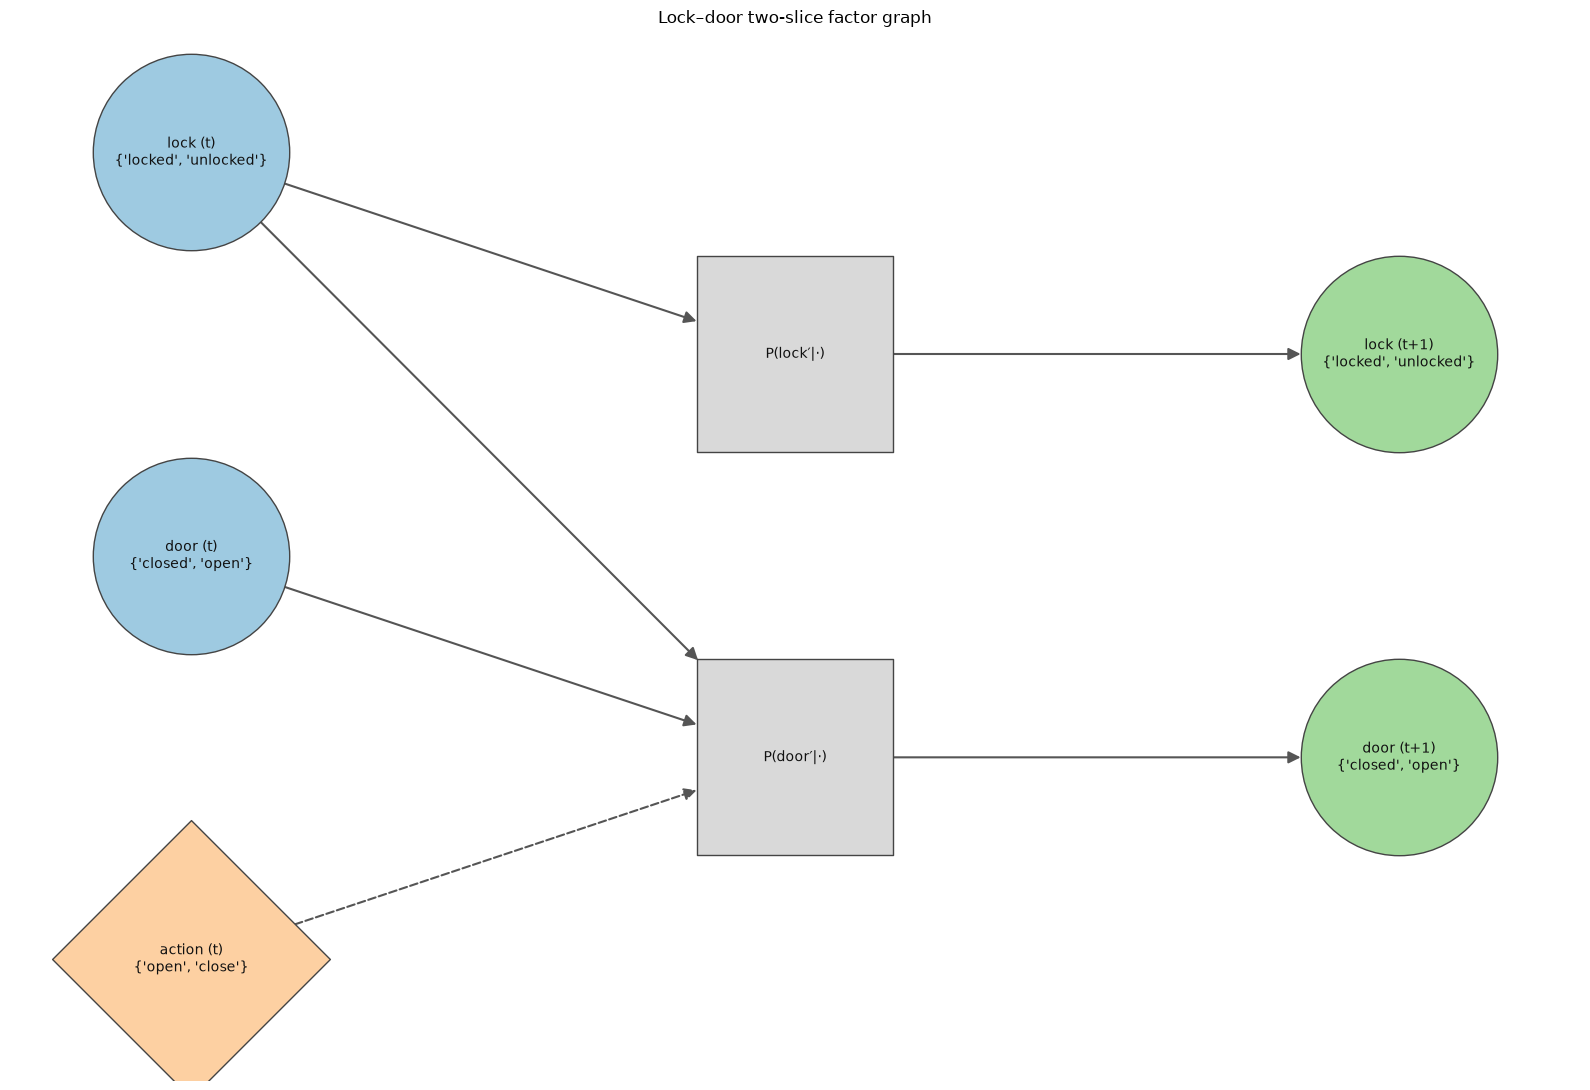

In [6]:
%matplotlib inline

import matplotlib.pyplot as plt

graph = world.to_networkx()

print("Nodes:")
for node, attributes in graph.nodes(data=True):
    print(f"  {node!r}: {attributes['role']} — {attributes['label']}")

print("\nEdges:")
for source, target, attributes in graph.edges(data=True):
    print(f"  {source!r} -> {target!r}: {attributes['kind']}")


def scaled_layered_layout(graph, *, x_scale=6, y_scale=6):
    """Spread out layered columns so multi-line labels fit inside node markers."""
    layers = {}
    for node, attributes in graph.nodes(data=True):
        layers.setdefault(int(attributes["layer"]), []).append(node)

    positions = {}
    for layer, nodes in layers.items():
        nodes.sort(
            key=lambda node: (
                graph.nodes[node].get("order", 0),
                repr(node),
            )
        )
        midpoint = (len(nodes) - 1) / 2.0
        for index, node in enumerate(nodes):
            positions[node] = (layer * x_scale, (midpoint - index) * y_scale)
    return positions


fig, ax = plt.subplots(figsize=(16, 11))
world.draw(
    ax=ax,
    show_domains=True,
    layout=scaled_layered_layout(graph),
    node_size=20_000,
    font_size=10,
)
ax.set_title("Lock–door two-slice factor graph")
fig.tight_layout()
plt.show()

## Check one product exactly

Start from an unlocked latch and a closed door, take `open`, and observe a locked latch with an open door. The lock changes with probability $0.05$, while the door opens with probability $0.9$ because its row is conditioned on the **current unlocked** setting. The joint probability should therefore be $0.045$.

In [7]:
current = {"lock": "unlocked", "door": "closed"}
parents = {"action": "open"}
next_state = {"lock": "locked", "door": "open"}

lock_probability = lock_factor.transition_probability(
    {"lock": "locked"},
    {"lock": "unlocked"},
)
door_probability = door_factor.transition_probability(
    {"door": "open"},
    {"door": "closed"},
    {"lock": "unlocked", "action": "open"},
)
joint_probability = world.transition_probability(next_state, current, parents)
expected_product = lock_probability * door_probability

assert isclose(joint_probability, expected_product, abs_tol=1e-12)
assert isclose(joint_probability, 0.045, abs_tol=1e-12)
print(f"{lock_probability:.2f} x {door_probability:.2f} = {joint_probability:.3f}")

0.05 x 0.90 = 0.045


## Exhaustive normalization checks

The next cell checks every row of each local factor and every joint context. For this example that means 2 lock rows, 8 door rows, and $2\times2\times2=8$ joint rows.

In [8]:
def probability_sum(distribution):
    return sum(probability for _, probability in distribution.items())


local_checks = 0
for lock_value in LOCK_VALUES:
    distribution = lock_factor.transition_distribution({"lock": lock_value})
    assert isclose(probability_sum(distribution), 1.0, abs_tol=1e-12)
    local_checks += 1

for door_value, lock_value, action_value in product(
    DOOR_VALUES, LOCK_VALUES, ACTION_VALUES
):
    distribution = door_factor.transition_distribution(
        {"door": door_value},
        {"lock": lock_value, "action": action_value},
    )
    assert isclose(probability_sum(distribution), 1.0, abs_tol=1e-12)
    local_checks += 1

joint_checks = 0
for lock_value, door_value, action_value in product(
    LOCK_VALUES, DOOR_VALUES, ACTION_VALUES
):
    distribution = world.transition_distribution(
        {"lock": lock_value, "door": door_value},
        {"action": action_value},
    )
    assert isclose(probability_sum(distribution), 1.0, abs_tol=1e-12)
    joint_checks += 1

print(f"All {local_checks} local rows and {joint_checks} joint rows sum to one.")

All 10 local rows and 8 joint rows sum to one.


## Compare action effects

For an unlocked latch and closed door, `open` should change the door marginal while leaving the lock marginal invariant. We compute both marginals from the joint model rather than consulting the component tables.

In [9]:
comparison = {}
for action_value in ACTION_VALUES:
    distribution = world.transition_distribution(
        {"lock": "unlocked", "door": "closed"},
        {"action": action_value},
    )
    lock_marginal = {
        next_lock: sum(
            probability
            for outcome, probability in distribution.items()
            if outcome["lock"] == next_lock
        )
        for next_lock in LOCK_VALUES
    }
    open_probability = sum(
        probability
        for outcome, probability in distribution.items()
        if outcome["door"] == "open"
    )
    comparison[action_value] = (lock_marginal, open_probability)

open_lock, open_door = comparison["open"]
close_lock, close_door = comparison["close"]
assert all(
    isclose(open_lock[value], close_lock[value], abs_tol=1e-12)
    for value in LOCK_VALUES
)
assert isclose(open_door, 0.9, abs_tol=1e-12)
assert isclose(close_door, 0.0, abs_tol=1e-12)

print("Action | P(next lock = unlocked) | P(next door = open)")
print("-------+-------------------------+--------------------")
for action_value in ACTION_VALUES:
    lock_marginal, open_probability = comparison[action_value]
    print(
        f"{action_value:6} | {lock_marginal['unlocked']:23.2f} | {open_probability:18.2f}"
    )

Action | P(next lock = unlocked) | P(next door = open)
-------+-------------------------+--------------------
open   |                    0.95 |               0.90
close  |                    0.95 |               0.00


## Takeaway

The same joint world contains a predictable-but-uncontrollable lock regularity and action-sensitive door dynamics. Factoring makes that distinction explicit: an agent can spend finite learning capacity on lock dynamics, door control, or both, while downstream tasks determine which knowledge is useful.